In [7]:
import dagshub
import mlflow
dagshub.init(repo_owner='MohammedTawfikEldeeb', repo_name='telcom-churn', mlflow=True)

Initialized MLflow to track repo "MohammedTawfikEldeeb/telcom-churn"

Repository MohammedTawfikEldeeb/telcom-churn initialized!

In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
# split the dataset
from sklearn.model_selection import train_test_split


# preprossing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , LabelEncoder , OrdinalEncoder
from sklearn.pipeline import Pipeline , FeatureUnion
from sklearn_features.transformers import DataFrameSelector
from datasist.structdata import detect_outliers
from sklearn.model_selection import cross_val_score, cross_val_predict
from imblearn.over_sampling import SMOTE ,RandomOverSampler , ADASYN

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , classification_report , confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression , SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import AdaBoostClassifier , BaggingClassifier , GradientBoostingClassifier , RandomForestClassifier , VotingClassifier
from sklearn.multiclass import OneVsOneClassifier
import xgboost as xgb


In [9]:
df = pd.read_csv('data/data_processed.csv')
df.head()

,account_length,international_plan,voice_mail_plan,number_vmail_messages,customer_service_calls,churn,total_charge,total_minutes,total_calls
0,128,0,1,25,1,False,75.56,717.2,303
1,107,0,1,26,1,False,59.24,625.2,332
2,137,0,0,0,0,False,62.29,539.4,333
3,84,1,0,0,2,False,66.80,564.8,255
4,75,1,0,0,3,False,52.09,512.0,359


In [10]:
outlieres_indicies = detect_outliers(df ,0, df.select_dtypes(include = ['float64' ,'int64']))
100*(len(outlieres_indicies)/df.shape[0])
df.drop(outlieres_indicies , inplace = True)

🏃 View run knn_with_SMOTE at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0/runs/6c1afa391b194e908ec4750084700027
🧪 View experiment at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0
SMOTE-knn -> Accuracy: 0.8579 | Precision: 0.3174 | Recall: 0.7162 | F1: 0.4398
🏃 View run SGD_with_SMOTE at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0/runs/ce72928dbffd460988bd4e4d929330b7
🧪 View experiment at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0
SMOTE-SGD -> Accuracy: 0.7653 | Precision: 0.2189 | Recall: 0.7838 | F1: 0.3422
🏃 View run Lgr_with_SMOTE at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0/runs/0c7244f6e84141889d7d01d2ee329db7
🧪 View experiment at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0
SMOTE-Lgr -> Accuracy: 0.7905 | Precision: 0.2407 | Recall: 0.7838 | F1: 0.3683
🏃 View run xgb_with_SMOTE at

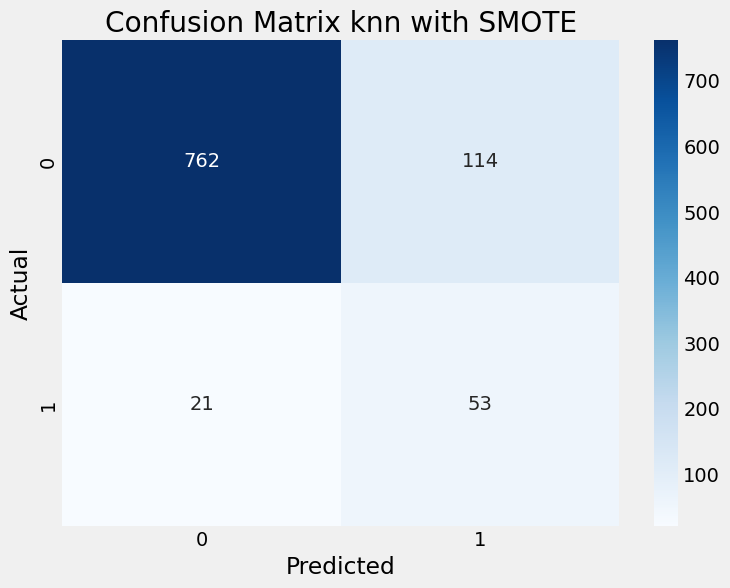

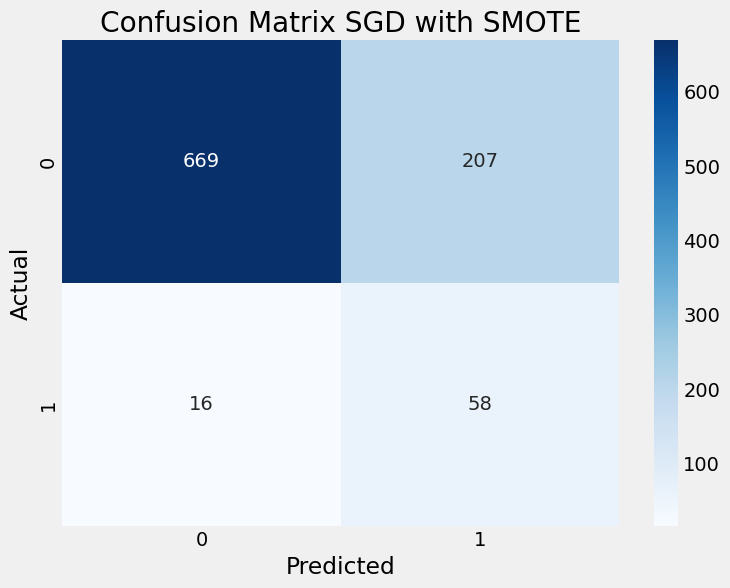

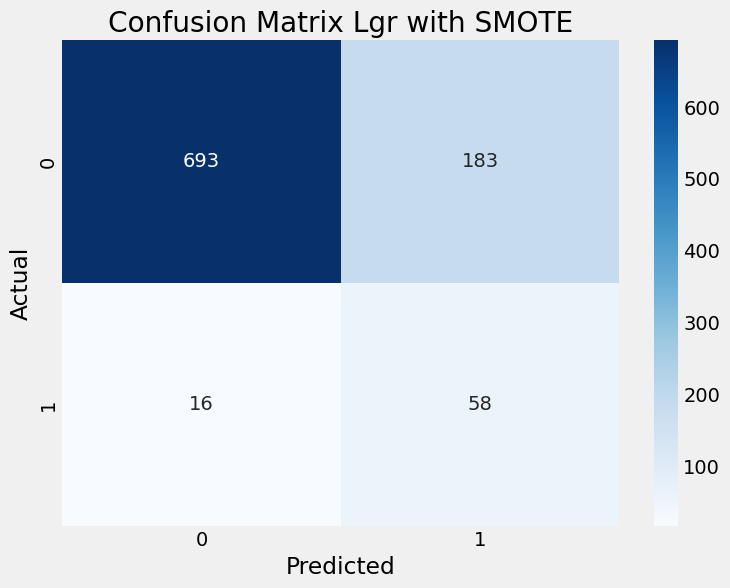

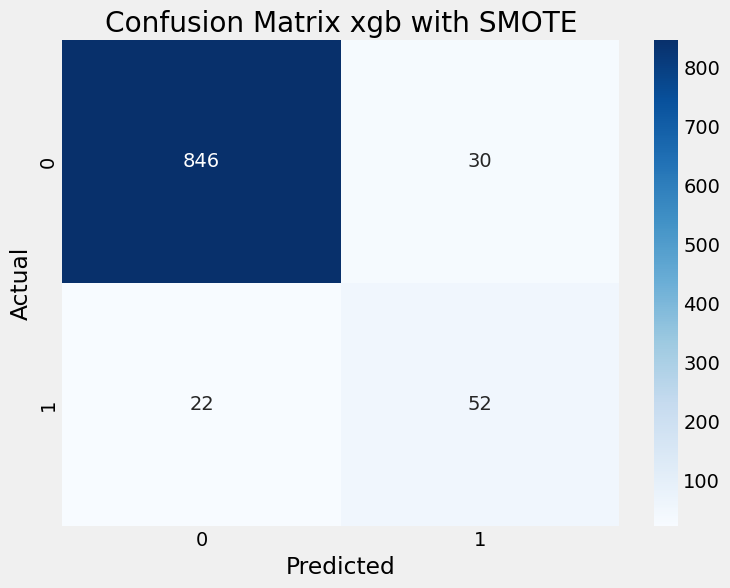

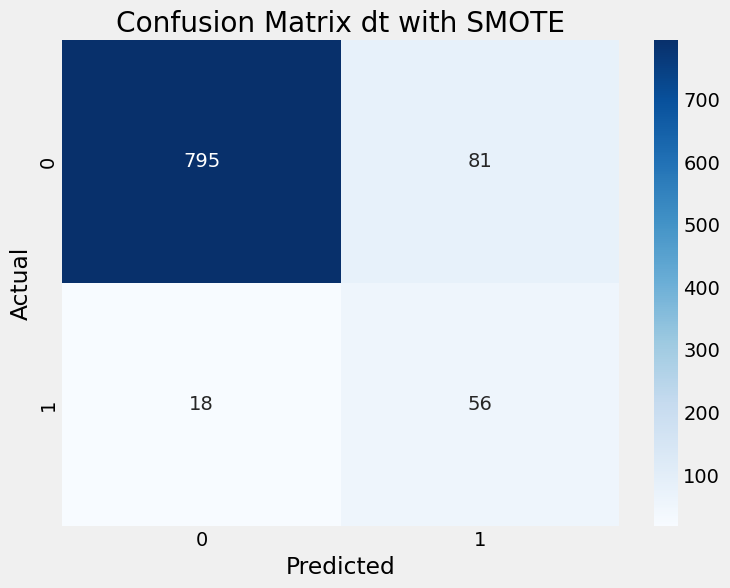

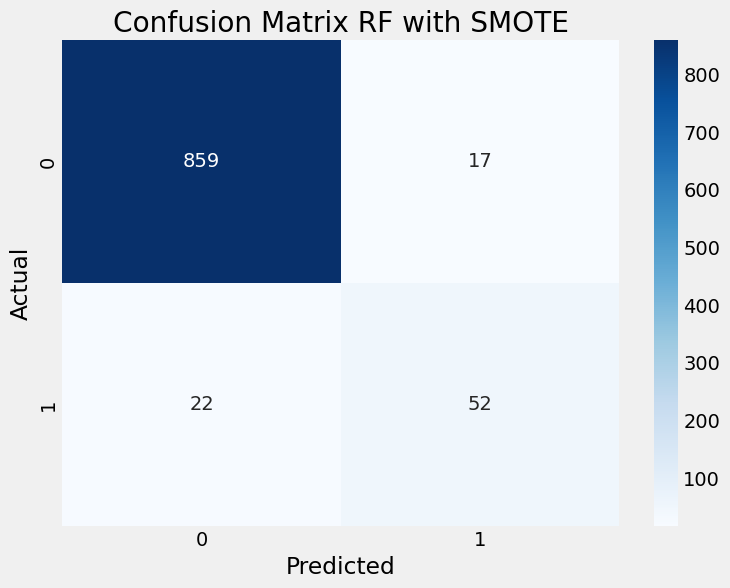

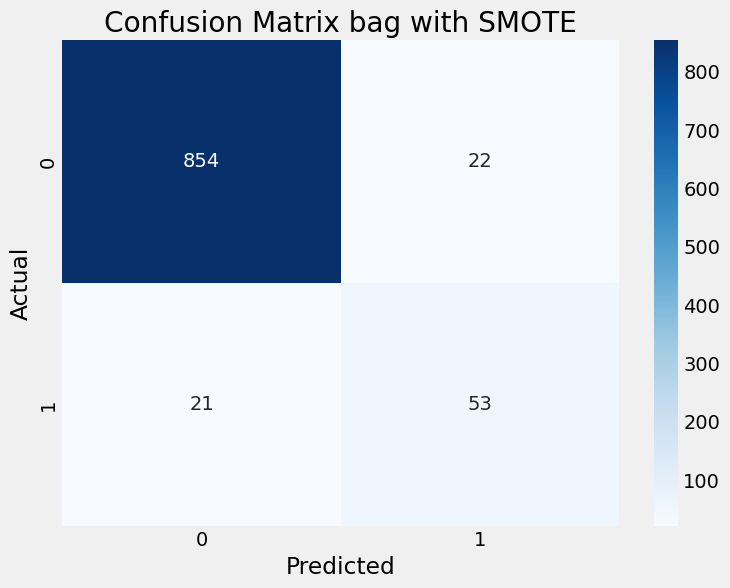

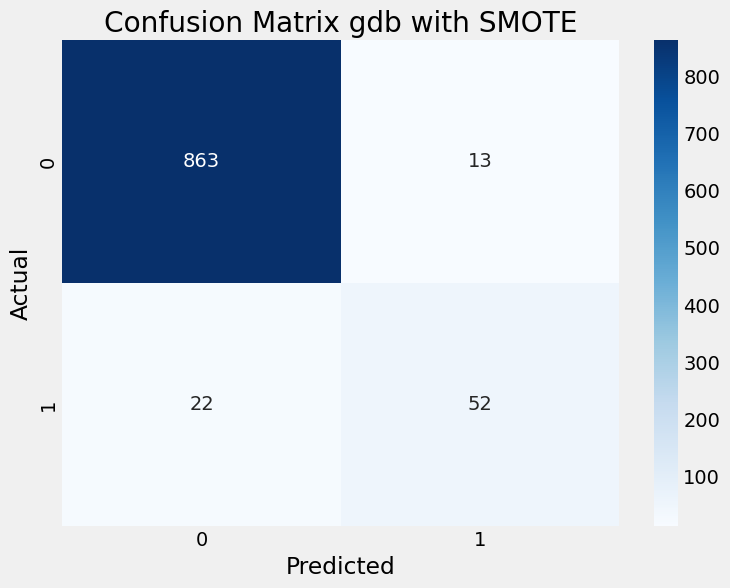

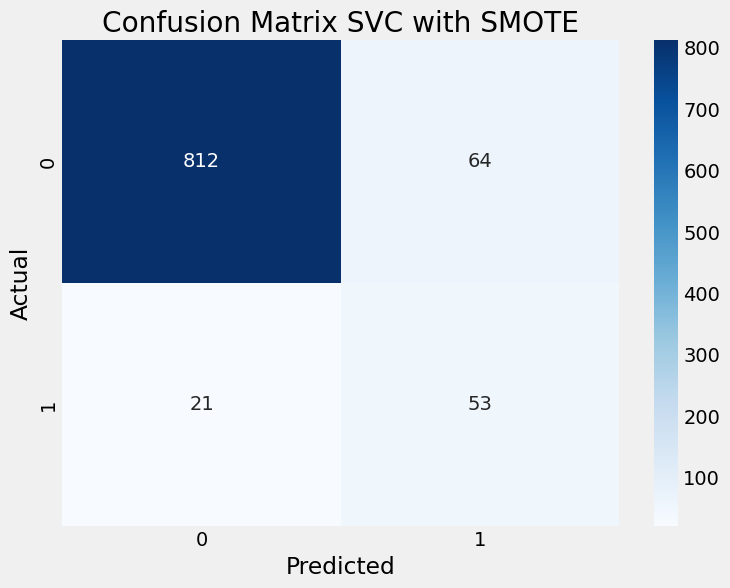

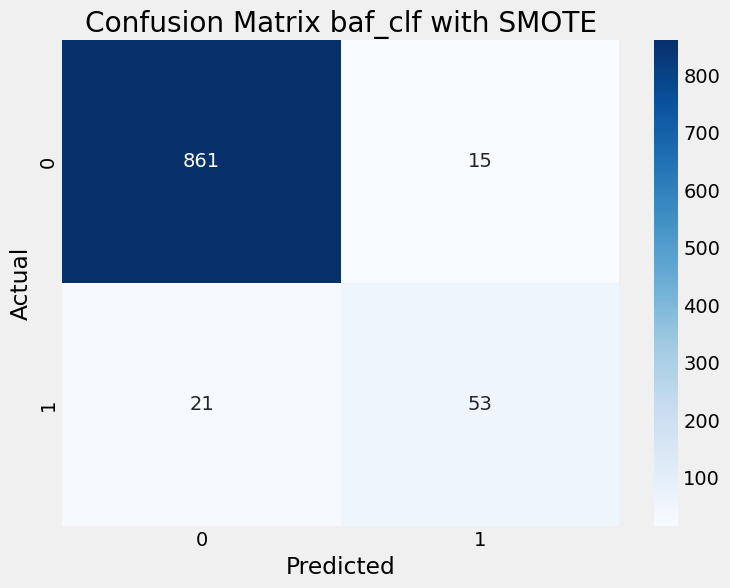

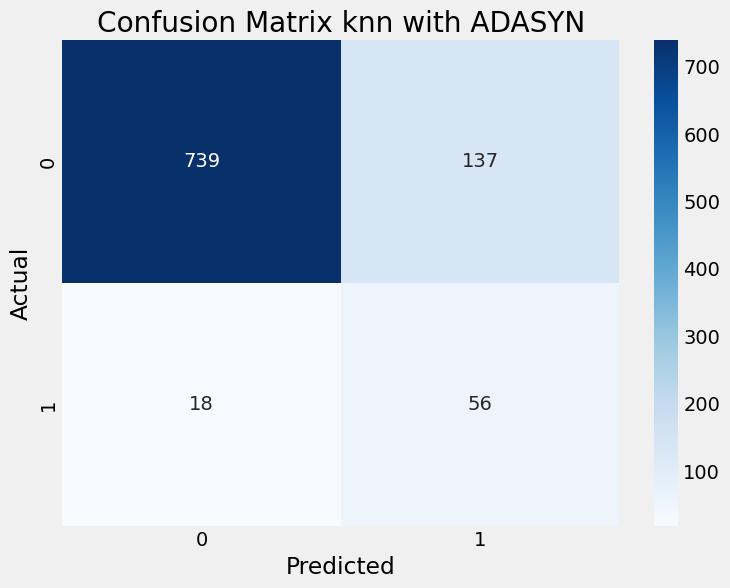

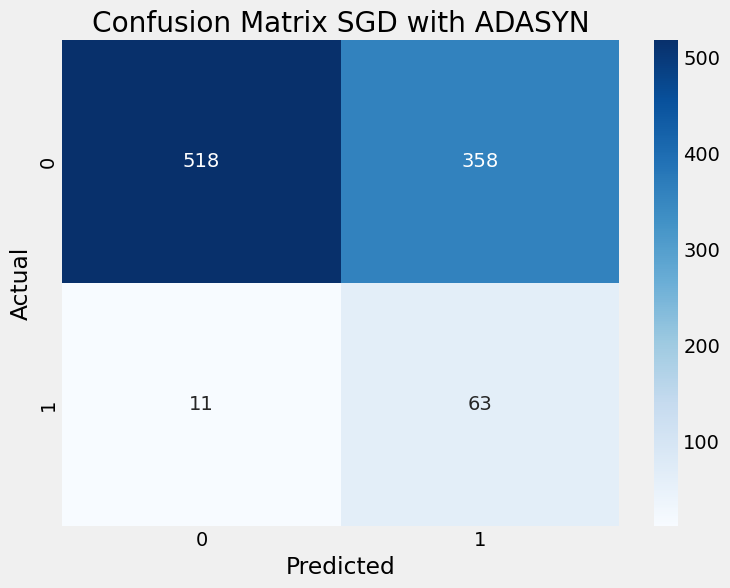

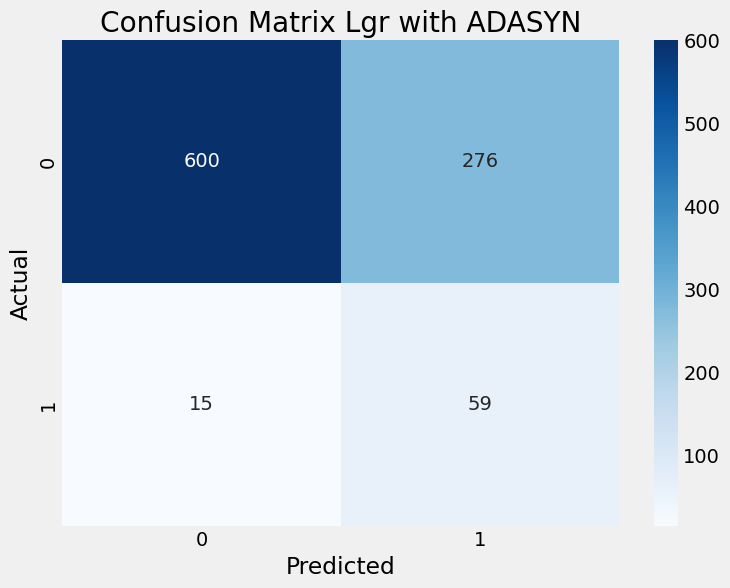

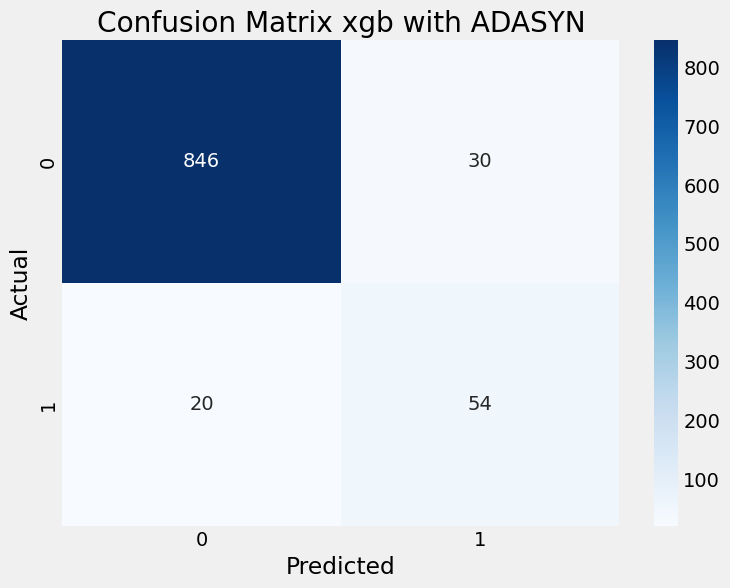

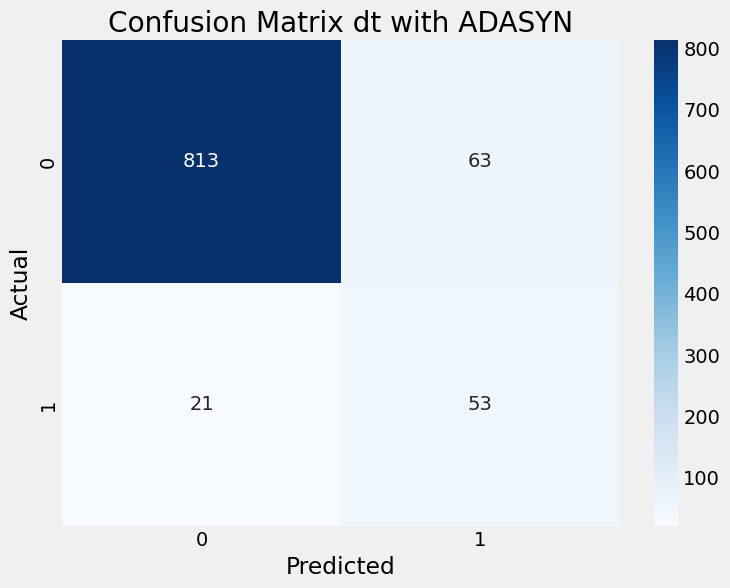

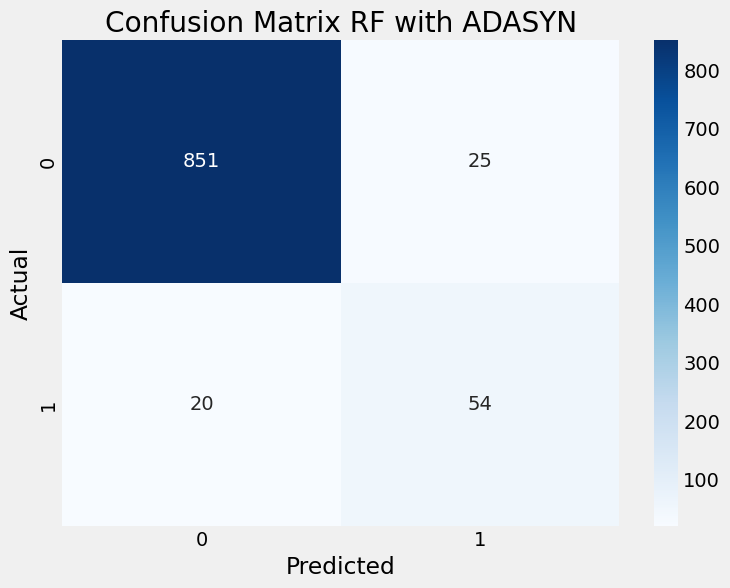

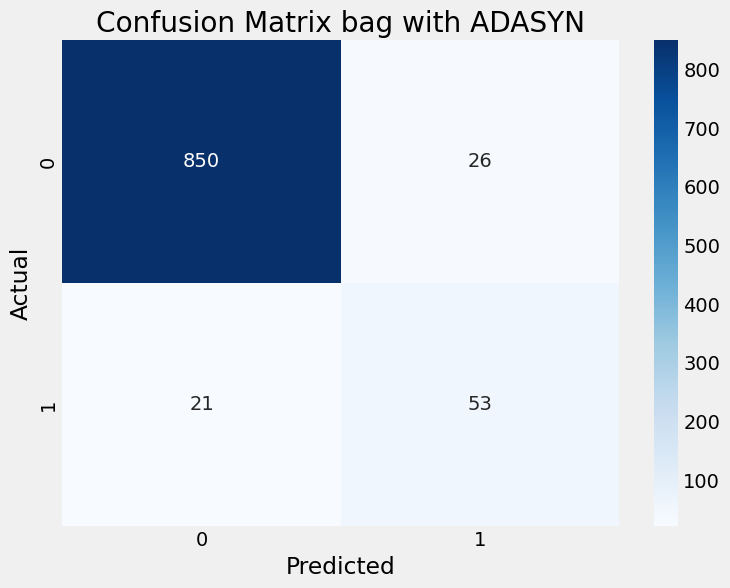

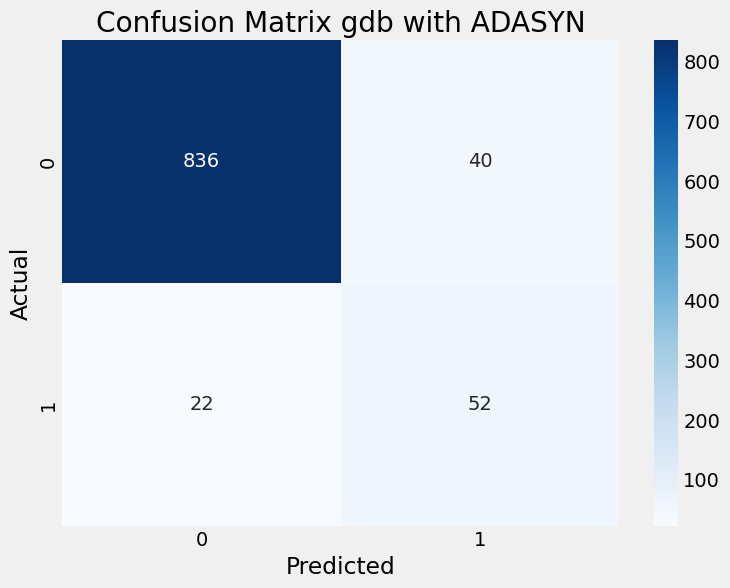

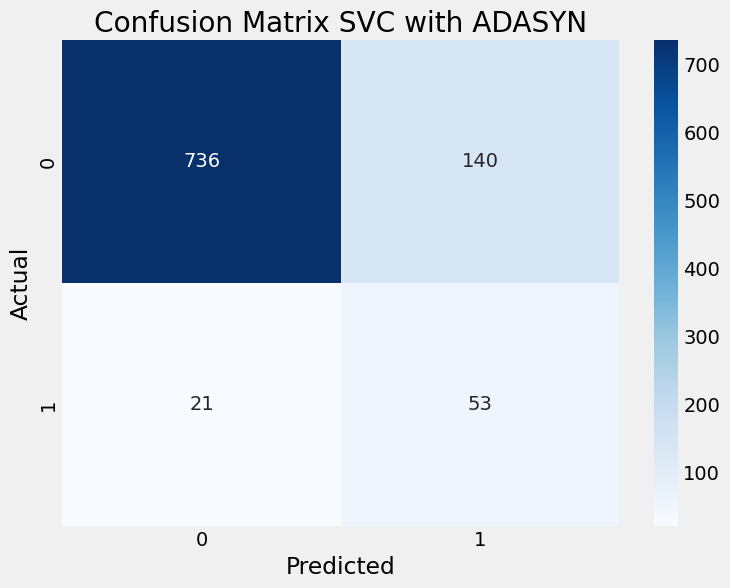

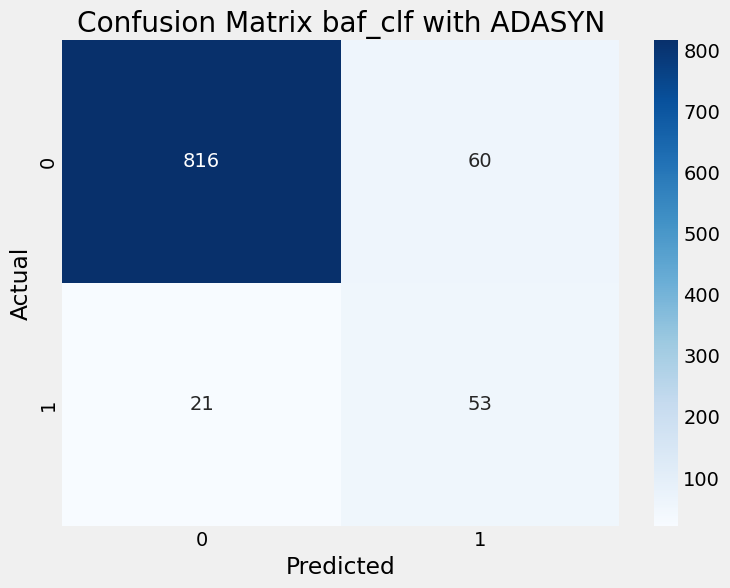

In [11]:

# -------- Split before sampling --------
X = df.drop('churn', axis=1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42, stratify=y, shuffle=True
)

# -------- Scaling --------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'knn': KNeighborsClassifier(),
    'SGD': SGDClassifier(random_state=42),
    'Lgr': LogisticRegression(max_iter=1000, random_state=42),
    'xgb': xgb.XGBClassifier(random_state=42),
    'dt': DecisionTreeClassifier(random_state=42),
    'RF': RandomForestClassifier(random_state=42),
    'bag': BaggingClassifier(random_state=42),
    'gdb': GradientBoostingClassifier(random_state=42),
    'SVC': SVC(),
    'baf_clf': BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=100, bootstrap=True, random_state=42)
}

samplers = {
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

for sampler_name, sampler in samplers.items():
    # -------- Oversample train only --------
    X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_scaled, y_train)

    for model_name, model in models.items():
        with mlflow.start_run():
            mlflow.set_tag("mlflow.runName", f"{model_name}_with_{sampler_name}")
            mlflow.set_tag("experiment_type", "model_comparison")

            # -------- Train model --------
            model.fit(X_train_resampled, y_train_resampled)
            y_pred = model.predict(X_test_scaled)

            # -------- Metrics --------
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)

            mlflow.log_metric("accuracy", accuracy)
            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)

            # -------- Classification Report --------
            classification_rep = classification_report(y_test, y_pred, output_dict=True)
            for label, metrics in classification_rep.items():
                if isinstance(metrics, dict):
                    for metric, value in metrics.items():
                        mlflow.log_metric(f"{label}_{metric}", value)

            # -------- Confusion Matrix --------
            conf_matrix = confusion_matrix(y_test, y_pred)
            plt.figure(figsize=(8, 6))
            sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.title(f"Confusion Matrix {model_name} with {sampler_name}")
            plt.savefig(f"confusion_matrix_{model_name}_with_{sampler_name}.png")
            mlflow.log_artifact(f"confusion_matrix_{model_name}_with_{sampler_name}.png")

            # -------- Dataset Snapshot --------
            df.to_csv("dataset.csv", index=False)
            mlflow.log_artifact("dataset.csv")

        print(f"{sampler_name}-{model_name} -> "
              f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")